# Line Emission Denoising — Beam-Conditioned U-Net + Hyperparameter Sweep

Per the 2026-07-20 mentor meeting (Jason): **stick with the U-Net** (V12 baseline: PSNR 32.95 dB / SSIM 0.9857 / MSE 0.000681; 5-cube holdout M0 +69.8%±15.2% / M1 +17.5%±7.8% / M2 +20.1%±14.3%). Two work items, in his priority order:

1. **Beam metadata (brief investigation)** — feed the observation's beam as a 4-vector `[sin(2·BPA), cos(2·BPA), BMAJ·3600, BMIN·3600]` (BPA deg→rad; BMAJ/BMIN deg→arcsec), embedded and added to the conditioning pathway so every block — including the upsampling path — sees the noise scale. If it doesn't help, drop it and move on.
2. **Random hyperparameter sweep** with early stopping (min ~15–20, max ~60–100 epochs, patience ~5): width, depth, lr, scheduler patience, loss weights, beam on/off. Random first; a Bayesian sweep seeded with these runs can follow. Every run scored on **fixed** metrics (PSNR/SSIM/MSE), never the swept loss.

Data pipeline unchanged from V12: continuum-subtracted line-emission channels, cube-level split, 256×256, shared-dirty-scale per-channel norm.

### Kaggle setup
GPU on, Internet on, Add Input → line-emission Dataset (FITS cubes).

## 0. Bootstrap (clone repo for src/, locate data)


In [1]:
import os, sys, subprocess, glob

ON_KAGGLE = os.path.exists('/kaggle')
if ON_KAGGLE:
    REPO='/kaggle/working/EXXA'; PKG=os.path.join(REPO,'DENOISING_DIFFUSION')
    if not os.path.exists(REPO):
        subprocess.run(['git','clone','--branch','line-emission','--depth','1','https://github.com/KrishanYadav333/EXXA.git',REPO], check=True)
    else:
        subprocess.run(['git','-C',REPO,'fetch','origin','line-emission'], check=True)
        subprocess.run(['git','-C',REPO,'reset','--hard','origin/line-emission'], check=True)
    # pytorch-msssim for the SSIM loss; bettermoments for moment-map evaluation (Sec. 9)
    subprocess.run([sys.executable,'-m','pip','install','-q','--no-deps','pytorch-msssim','bettermoments'], check=True)
    os.chdir(os.path.join(PKG,'notebooks'));  sys.path.insert(0, PKG)
    # find the line-emission data dir under /kaggle/input (contains run_* subfolders)
    hits = glob.glob('/kaggle/input/**/*_dirty.fits', recursive=True)
    DATA_DIR = os.path.dirname(os.path.dirname(hits[0])) if hits else None
else:
    if os.path.basename(os.getcwd()) != 'notebooks' and os.path.isdir('notebooks'): os.chdir('notebooks')
    sys.path.insert(0, os.path.abspath('..'))
    DATA_DIR = '../data/Line Emission Data'
print('cwd:', os.getcwd(), '| DATA_DIR:', DATA_DIR)

Cloning into '/kaggle/working/EXXA'...
Updating files: 100% (5081/5081), done.


cwd: /kaggle/working/EXXA/DENOISING_DIFFUSION/notebooks | DATA_DIR: /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data


## 0b. Pull latest code (re-run anytime ├óΓé¼ΓÇ¥ NO kernel restart needed)

After I push new changes to the `line-emission` branch, just **re-run this one cell** to fetch them
and hot-reload the `src/` modules. Then re-run the import cell below. No "Restart & Run All" required.

In [2]:
# Pull latest from the line-emission branch and hot-reload src/ (no kernel restart).
# Self-contained: works even if the bootstrap cell hasn't run in this kernel.
import os, sys, subprocess

ON_KAGGLE = os.path.exists('/kaggle')
REPO = '/kaggle/working/EXXA'

if ON_KAGGLE and os.path.exists(REPO):
    subprocess.run(['git', '-C', REPO, 'fetch', 'origin', 'line-emission'], check=True)
    subprocess.run(['git', '-C', REPO, 'reset', '--hard', 'origin/line-emission'], check=True)
    print(subprocess.run(['git', '-C', REPO, 'log', '--oneline', '-1'],
                         capture_output=True, text=True).stdout.strip())
elif ON_KAGGLE:
    print('repo not cloned yet ├óΓé¼ΓÇ¥ run the bootstrap cell (0.) first')

# drop cached project modules so the next `import` picks up the freshly pulled code
for _m in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[_m]
print('src.* cleared from module cache ├óΓé¼ΓÇ¥ now re-run the imports cell below.')

From https://github.com/KrishanYadav333/EXXA
 * branch            line-emission -> FETCH_HEAD


HEAD is now at 09bfcb9 move: relocate DDPM notebook to repo root, out of notebooks/ subfolder
09bfcb9 move: relocate DDPM notebook to repo root, out of notebooks/ subfolder
src.* cleared from module cache ├óΓé¼ΓÇ¥ now re-run the imports cell below.


## 1. Imports, device, config


In [3]:
import math, time
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.data.cube_split import split_cubes
from src.data.fits_cube_dataset import FITSChannelDataset, beam_features_of, continuum_of
from src.models.unet import UNet
from src.training.sweep import train_unet, run_sweep, val_metrics, SPACE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPU  = torch.cuda.device_count()
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print('device:', device, '| GPUs:', N_GPU,
      '->', [torch.cuda.get_device_name(i) for i in range(N_GPU)] if N_GPU else 'cpu')

TARGET_SIZE = 256
N_SAMPLES   = 50      # V12-comparable; the sweep uses the same for run-time parity
BATCH_SIZE  = 32
NW          = 4 if ON_KAGGLE else 0   # FITS I/O bottleneck; workers help on Kaggle

# V12 reference numbers (fixed 30-epoch run) for the comparison printouts
V12 = {'psnr': 32.95, 'ssim': 0.9857, 'mse': 0.000681}

device: cuda | GPUs: 2 -> ['Tesla T4', 'Tesla T4']


## 2. Cube-level split (3 RunID groups held out for inference only)


In [4]:
train_cubes, val_cubes, holdout_cubes = split_cubes(data_dir=DATA_DIR, n_holdout=3,
                                                     val_fraction=0.2, seed=SEED)

CUBE-LEVEL SPLIT (grouped by RunID — no channel-level leakage)
  data_dir          : /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data
  total cubes       : 14  across 11 distinct RunIDs
  seed=42  n_holdout=3  val_fraction=0.2
----------------------------------------------------------------------
  TRAIN   :  7 cubes | RunIDs ['0006', '0010', '0020', '0022', '0030', '0035']
  VAL     :  2 cubes | RunIDs ['0016', '0036']
  HOLDOUT :  5 cubes | RunIDs ['0002', '0025', '0026']  <-- inference only, NEVER trained/validated
----------------------------------------------------------------------
  HOLDOUT cube folders (reserved for moment-map evaluation):
    - run_0002_00560_rt_00
    - run_0002_00560_rt_01
    - run_0002_00560_rt_04
    - run_0025_01000_rt_04
    - run_0026_00005_rt_04


## 3. Datasets — continuum-subtracted pairs + per-cube beam vector

`return_beam=True` adds the 4-feature beam vector (from each cube's **dirty** header) to every
item. The printout below shows the per-cube vectors — **if they are identical across cubes, beam
conditioning carries no information for this dataset** and the experiment is a null by
construction (worth knowing before reading the A/B numbers).

In [5]:
SUBTRACT_CONTINUUM = True
CONTINUUM_N        = 5
train_ds = FITSChannelDataset(train_cubes, n_samples=N_SAMPLES, target_size=TARGET_SIZE, seed=SEED,
                              subtract_continuum=SUBTRACT_CONTINUUM, continuum_n=CONTINUUM_N,
                              return_beam=True)
val_ds   = FITSChannelDataset(val_cubes,   n_samples=N_SAMPLES, target_size=TARGET_SIZE, seed=SEED,
                              subtract_continuum=SUBTRACT_CONTINUUM, continuum_n=CONTINUUM_N,
                              return_beam=True)
print('train items:', len(train_ds), '| val items:', len(val_ds))
print('\nper-cube beam vectors [sin2BPA, cos2BPA, bmaj\", bmin\"]:')
for (cl, dr, tag), bv in zip(train_ds.cube_paths, train_ds.beam_vectors):
    print(f'  {tag:<28} {[round(v, 5) for v in bv.tolist()]}')

[FITSChannelDataset] 7 cubes x ~50 channels = 350 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
[FITSChannelDataset] 2 cubes x ~50 channels = 100 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
train items: 350 | val items: 100

per-cube beam vectors [sin2BPA, cos2BPA, bmaj", bmin"]:
  run_0006_00170_rt_00         [-0.35688, 0.93415, 0.16325, 0.14323]
  run_0010_00125_rt_01         [-0.88444, -0.46665, 0.178, 0.11162]
  run_0010_00125_rt_02         [0.99896, 0.04559, 0.10449, 0.09915]
  run_0020_01000_rt_02         [-0.45252, -0.89175, 0.14064, 0.10718]
  run_0022_00155_rt_03         [0.99906, 0.04339, 0.13931, 0.13261]
  run_0030_00015_rt_00         [-0.99632, 0.08566, 0.1538, 0.12479]
  run_0035_00025_rt_01         [0.78691, 0.61707, 0.15059, 0.14761]


## 4. Beam A/B — identical training harness, only `use_beam` differs

Both runs use the V12 architecture (base 32, mult 1-2-4) and loss (0.8·MSE + 0.2·(1−SSIM)) with
early stopping (min 20 / max 60 / patience 5). Comparing the beam run against the **control**
(not just against V12) keeps the early-stopping change out of the beam verdict.

In [6]:
CKPT_BEAM = '../results/checkpoints/unet_line_emission_beam_best.pth'
CKPT_CTRL = '../results/checkpoints/unet_line_emission_ctrl_best.pth'

common = dict(base_channels=32, channel_multipliers=(1, 2, 4), lr=1e-3, alpha=0.8,
              batch_size=BATCH_SIZE, min_epochs=20, max_epochs=60, patience=5,
              sched_patience=5, num_workers=NW, seed=SEED)

print('=== control (no beam) ===')
res_ctrl = train_unet(train_ds, val_ds, device, use_beam=False, ckpt_path=CKPT_CTRL, **common)
print(f"control: PSNR {res_ctrl['psnr']:.4f} | SSIM {res_ctrl['ssim']:.4f} | "
      f"MSE {res_ctrl['mse']:.6f} | best ep {res_ctrl['best_epoch']} "
      f"({res_ctrl['epochs_run']} run)")

print('\n=== beam-conditioned ===')
res_beam = train_unet(train_ds, val_ds, device, use_beam=True, ckpt_path=CKPT_BEAM, **common)
print(f"beam   : PSNR {res_beam['psnr']:.4f} | SSIM {res_beam['ssim']:.4f} | "
      f"MSE {res_beam['mse']:.6f} | best ep {res_beam['best_epoch']} "
      f"({res_beam['epochs_run']} run)")

=== control (no beam) ===
  ep   1 | train 0.2116 | val 0.0537 | lr 1.0e-03 (19s) *best
  ep   2 | train 0.0301 | val 0.0279 | lr 1.0e-03 (12s) *best
  ep   3 | train 0.0241 | val 0.0280 | lr 1.0e-03 (12s)
  ep   4 | train 0.0194 | val 0.0238 | lr 1.0e-03 (12s) *best
  ep   5 | train 0.0131 | val 0.0144 | lr 1.0e-03 (12s) *best
  ep   6 | train 0.0123 | val 0.0120 | lr 1.0e-03 (12s) *best
  ep   7 | train 0.0093 | val 0.0092 | lr 1.0e-03 (12s) *best
  ep   8 | train 0.0082 | val 0.0086 | lr 1.0e-03 (12s) *best
  ep   9 | train 0.0071 | val 0.0080 | lr 1.0e-03 (13s) *best
  ep  10 | train 0.0073 | val 0.0106 | lr 1.0e-03 (13s)
  ep  11 | train 0.0102 | val 0.0102 | lr 1.0e-03 (13s)
  ep  12 | train 0.0077 | val 0.0070 | lr 1.0e-03 (13s) *best
  ep  13 | train 0.0065 | val 0.0070 | lr 1.0e-03 (13s) *best
  ep  14 | train 0.0067 | val 0.0072 | lr 1.0e-03 (13s)
  ep  15 | train 0.0063 | val 0.0072 | lr 1.0e-03 (13s)
  ep  16 | train 0.0058 | val 0.0060 | lr 1.0e-03 (13s) *best
  ep  17 | t

## 5. Loss curves + verdict


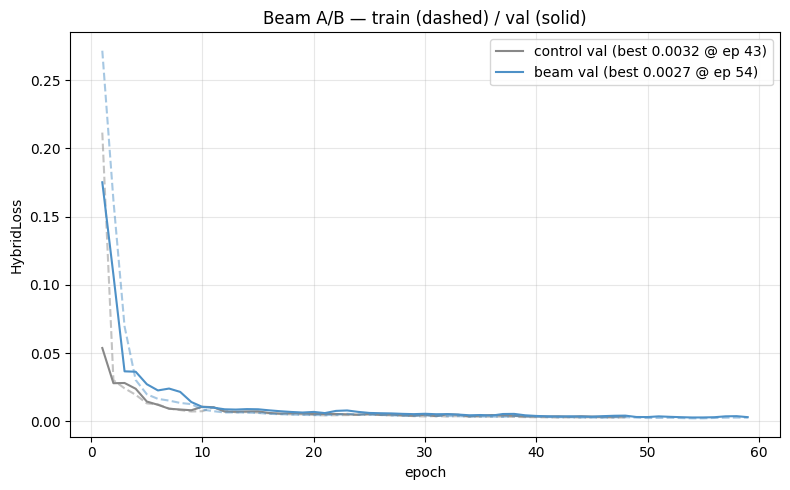

beam - control: PSNR +1.242 dB | SSIM +0.00169
V12 reference : PSNR 32.95 | SSIM 0.9857 | MSE 0.000681
verdict: beam helps


In [7]:
plt.figure(figsize=(8, 5))
for res, name, color in [(res_ctrl, 'control', '#888888'), (res_beam, 'beam', '#4E91C7')]:
    plt.plot(range(1, len(res['train_losses'])+1), res['train_losses'], '--', color=color, alpha=0.5)
    plt.plot(range(1, len(res['val_losses'])+1), res['val_losses'], '-', color=color,
             label=f"{name} val (best {res['best_val_loss']:.4f} @ ep {res['best_epoch']})")
plt.xlabel('epoch'); plt.ylabel('HybridLoss'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Beam A/B — train (dashed) / val (solid)')
plt.tight_layout(); plt.savefig('../experiments/beam_ab_loss.png', dpi=140); plt.show()

d_psnr = res_beam['psnr'] - res_ctrl['psnr']
d_ssim = res_beam['ssim'] - res_ctrl['ssim']
print(f"beam - control: PSNR {d_psnr:+.3f} dB | SSIM {d_ssim:+.5f}")
print(f"V12 reference : PSNR {V12['psnr']} | SSIM {V12['ssim']} | MSE {V12['mse']}")
print('verdict:', 'beam helps' if d_psnr > 0.1 else
      'beam does not help materially -- per Jason, drop it and move to the sweep')

## 6. All-5-Holdout moment maps (beam model)

Same evaluation contract as V12's Section 11: denoise every channel of all 5 held-out cubes,
rebuild, compare M0/M1/M2 against clean vs the dirty baseline. The beam vector for each holdout
cube comes from its own dirty header via `beam_features_of`.

In [8]:
import os, csv
import torch.nn.functional as F
import matplotlib.ticker as mticker
import bettermoments as bm
from astropy.io import fits
from src.evaluation.moment_maps import generate_moment_maps

OUT_DIR = '../results'
BS = 32
os.makedirs(OUT_DIR, exist_ok=True)

ckpt = torch.load(CKPT_BEAM, map_location=device, weights_only=False)
eval_net = UNet(in_channels=1, out_channels=1, base_channels=ckpt['base_channels'],
                channel_multipliers=ckpt['channel_multipliers'], time_emb_dim=128,
                num_res_blocks=2, groups=math.gcd(8, ckpt['base_channels']),
                beam_dim=ckpt.get('beam_dim', 0)).to(device)
eval_net.load_state_dict(ckpt['model_state_dict']); eval_net.eval()
print('beam checkpoint loaded: epoch', ckpt.get('epoch'), '| val_loss',
      round(float(ckpt.get('val_loss', float('nan'))), 4), '| beam_dim', ckpt.get('beam_dim'))

def mdiff(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    return float(np.nanmean(np.abs(a[mask] - b[mask])))

def denoise_cube_beam(ho_entry, net):
    with fits.open(ho_entry['dirty'], memmap=False) as hdul:
        dirty_raw = np.ascontiguousarray(hdul[0].data).astype(np.float32)
        hdr = hdul[0].header.copy()
    beam_vec = torch.from_numpy(beam_features_of(hdr)).to(device)
    C, H, W = dirty_raw.shape
    dcont = continuum_of(dirty_raw, CONTINUUM_N)
    dirty_csub = dirty_raw - dcont[None, :, :]
    los  = dirty_csub.reshape(C, -1).min(axis=1)
    his  = dirty_csub.reshape(C, -1).max(axis=1)
    rngs = his - los
    norm = np.zeros_like(dirty_csub)
    nz = rngs > 0
    norm[nz] = (dirty_csub[nz] - los[nz, None, None]) / rngs[nz, None, None]

    denoised_csub = np.empty_like(dirty_csub)
    with torch.no_grad():
        for s in range(0, C, BS):
            t = torch.from_numpy(norm[s:s+BS])[:, None].float().to(device)
            t256 = F.interpolate(t, (TARGET_SIZE, TARGET_SIZE), mode='bilinear', align_corners=False)
            tz = torch.zeros(t256.size(0), dtype=torch.long, device=device)
            bb = beam_vec[None].expand(t256.size(0), -1)
            out = net(t256, tz, bb)
            out600 = F.interpolate(out, (H, W), mode='bilinear', align_corners=False)[:, 0].cpu().numpy()
            for k in range(out600.shape[0]):
                ch = s + k
                denoised_csub[ch] = (out600[k] * rngs[ch] + los[ch]) if rngs[ch] > 0 else \
                                    np.full((H, W), los[ch], np.float32)
    out_path = os.path.join(OUT_DIR, 'denoised_beam_' + ho_entry['folder'] + '.fits')
    fits.writeto(out_path, denoised_csub.astype(np.float32), header=hdr, overwrite=True)
    return out_path, dirty_csub

rows_data = []
col_w = 30
hdr_line = '{:<{w}} {:>10} {:>10} {:>10} {:>10} {:>10} {:>10}'.format(
    'cube', 'dirty_M0', 'imp_M0%', 'dirty_M1', 'imp_M1%', 'dirty_M2', 'imp_M2%', w=col_w)
print('\n' + hdr_line); print('-' * len(hdr_line))

for ho in holdout_cubes:
    print('  denoising', ho['folder'], '...', end=' ', flush=True)
    out_fits_ho, dirty_csub = denoise_cube_beam(ho, eval_net)
    print('done')
    with fits.open(ho['clean'], memmap=False) as h:
        clean_raw = np.ascontiguousarray(h[0].data).astype(np.float32)
    ccont = continuum_of(clean_raw, CONTINUUM_N)
    clean_csub = clean_raw - ccont[None]
    _, velax = bm.load_cube(ho['dirty'])
    c0, c1, c2 = generate_moment_maps(None, data_velax=(clean_csub, velax))
    d0, d1, d2 = generate_moment_maps(None, data_velax=(dirty_csub, velax))
    n0, n1, n2 = generate_moment_maps(out_fits_ho)
    row = {'cube': ho['folder']}
    for nm, cl, di, no in [('M0', c0, d0, n0), ('M1', c1, d1, n1), ('M2', c2, d2, n2)]:
        dd = mdiff(cl, di); nn = mdiff(cl, no)
        imp = 100.0 * (1 - nn / dd) if dd > 0 else float('nan')
        row['dirty_' + nm] = round(dd, 6); row['imp_' + nm] = round(imp, 2)
    rows_data.append(row)
    print('{:<{w}} {:>10.4g} {:>9.1f}% {:>10.4g} {:>9.1f}% {:>10.4g} {:>9.1f}%'.format(
        ho['folder'], row['dirty_M0'], row['imp_M0'], row['dirty_M1'], row['imp_M1'],
        row['dirty_M2'], row['imp_M2'], w=col_w))

moments = ['M0', 'M1', 'M2']
imps  = {m: [r['imp_'+m] for r in rows_data if r['imp_'+m] == r['imp_'+m]] for m in moments}
means = {m: float(np.mean(imps[m])) for m in moments}
stds  = {m: float(np.std(imps[m], ddof=1)) if len(imps[m]) > 1 else 0.0 for m in moments}
print('\n' + '=' * len(hdr_line))
print('BEAM SUMMARY (n=' + str(len(rows_data)) + ' cubes)  [V12 baseline: M0 +69.8+/-15.2, M1 +17.5+/-7.8, M2 +20.1+/-14.3]:')
for m in moments:
    print('  ' + m + ': mean {:+.1f}%  std {:.1f}%  (n={})'.format(means[m], stds[m], len(imps[m])))

csv_path = os.path.join(OUT_DIR, 'moment_map_holdout_summary_beam.csv')
fieldnames = ['cube', 'dirty_M0', 'imp_M0', 'dirty_M1', 'imp_M1', 'dirty_M2', 'imp_M2']
with open(csv_path, 'w', newline='') as cf:
    w = csv.DictWriter(cf, fieldnames=fieldnames); w.writeheader()
    for r in rows_data: w.writerow(r)
    w.writerow({'cube': 'MEAN', **{'imp_'+m: round(means[m], 2) for m in moments},
                **{'dirty_'+m: '' for m in moments}})
    w.writerow({'cube': 'STD',  **{'imp_'+m: round(stds[m], 2) for m in moments},
                **{'dirty_'+m: '' for m in moments}})
print('\nCSV saved ->', csv_path)

beam checkpoint loaded: epoch 54 | val_loss 0.0027 | beam_dim 4

cube                             dirty_M0    imp_M0%   dirty_M1    imp_M1%   dirty_M2    imp_M2%
------------------------------------------------------------------------------------------------
  denoising run_0002_00560_rt_00 ... done
run_0002_00560_rt_00             0.006489      75.7%     0.7699      14.0%      5.017      12.3%
  denoising run_0002_00560_rt_01 ... done
run_0002_00560_rt_01             0.004833      75.7%     0.4649      34.1%      5.343      24.7%
  denoising run_0002_00560_rt_04 ... done
run_0002_00560_rt_04             0.006434      60.0%     0.3272      15.1%      5.392       6.4%
  denoising run_0025_01000_rt_04 ... done
run_0025_01000_rt_04             0.004987       3.0%     0.6145      17.4%      4.907      57.4%
  denoising run_0026_00005_rt_04 ... done
run_0026_00005_rt_04             0.008393      84.8%      1.141      15.7%      3.534      15.1%

BEAM SUMMARY (n=5 cubes)  [V12 baseline: M0 +

## 7. Random hyperparameter sweep

Jason's method: **random search first** (this section), then a Bayesian sweep seeded with these
runs once the statistics justify it (W&B optional — this is the manual version). Swept: width,
depth, lr (log-uniform), HybridLoss α (β=1−α), scheduler patience, beam on/off. Fixed scoring
metric: **PSNR** (SSIM/MSE recorded too). Early stopping min 15 / max 60 / patience 5.

Each run appends its row to `results/sweep_results.csv` immediately, so a dead Kaggle session
keeps every completed run.

In [9]:
N_SWEEP_RUNS = 12   # ~15-25 min/run with early stopping on T4x2

print('search space:')
for k, v in SPACE.items(): print(f'  {k}: {v}')

sweep_results = run_sweep(train_ds, val_ds, device,
                          n_runs=N_SWEEP_RUNS,
                          out_csv='../results/sweep_results.csv',
                          seed=SEED, batch_size=BATCH_SIZE,
                          min_epochs=15, max_epochs=60, patience=5,
                          num_workers=NW, verbose=True)

search space:
  base_channels: [16, 32, 48, 64]
  channel_multipliers: [(1, 2, 4), (1, 2, 2, 4), (1, 2, 4, 8)]
  lr: (0.0001, 0.003)
  alpha: (0.5, 0.95)
  sched_patience: [3, 5, 8]
  use_beam: [False, True]

=== sweep run 1/12: {'base_channels': 16, 'channel_multipliers': (1, 2, 4), 'lr': 0.0012455466690609286, 'alpha': 0.6102013342115643, 'sched_patience': 3, 'use_beam': False} ===
  ep   1 | train 0.2024 | val 0.0529 | lr 1.2e-03 (7s) *best
  ep   2 | train 0.0340 | val 0.0471 | lr 1.2e-03 (7s) *best
  ep   3 | train 0.0274 | val 0.0264 | lr 1.2e-03 (7s) *best
  ep   4 | train 0.0202 | val 0.0202 | lr 1.2e-03 (7s) *best
  ep   5 | train 0.0151 | val 0.0148 | lr 1.2e-03 (7s) *best
  ep   6 | train 0.0146 | val 0.0158 | lr 1.2e-03 (7s)
  ep   7 | train 0.0134 | val 0.0139 | lr 1.2e-03 (7s) *best
  ep   8 | train 0.0117 | val 0.0142 | lr 1.2e-03 (7s)
  ep   9 | train 0.0135 | val 0.0149 | lr 1.2e-03 (7s)
  ep  10 | train 0.0128 | val 0.0129 | lr 1.2e-03 (7s) *best
  ep  11 | train 0.01

## 8. Sweep analysis — top configs + what correlates with PSNR


In [10]:
import pandas as pd

df = pd.read_csv('../results/sweep_results.csv')
df = df[pd.to_numeric(df['psnr'], errors='coerce').notna()].copy()
for c in ['psnr', 'ssim', 'mse', 'lr', 'alpha', 'base_channels', 'best_epoch']:
    df[c] = pd.to_numeric(df[c])
df['use_beam'] = df['use_beam'].astype(str).str.lower().isin(['true', '1'])

print(f'{len(df)} completed runs\n')
cols = ['base_channels', 'channel_multipliers', 'lr', 'alpha', 'use_beam',
        'best_epoch', 'psnr', 'ssim', 'mse']
print('top 5 by PSNR:')
print(df.sort_values('psnr', ascending=False)[cols].head(5).to_string(index=False))

print(f"\nV12 baseline PSNR: {V12['psnr']} dB")
print('\ncorrelation with PSNR (|r| ~ importance):')
for col, series in [('log10(lr)', np.log10(df['lr'])), ('alpha', df['alpha']),
                    ('base_channels', df['base_channels']),
                    ('use_beam', df['use_beam'].astype(float))]:
    if series.nunique() > 1:
        print(f'  {col:<14} r = {np.corrcoef(series, df.psnr)[0, 1]:+.3f}')
print('\nnext (per Jason): if a param stands out, seed a Bayesian sweep with these runs')

12 completed runs

top 5 by PSNR:
 base_channels channel_multipliers       lr    alpha  use_beam  best_epoch      psnr     ssim      mse
            48             1x2x4x8 0.000820 0.887768     False          33 37.109199 0.990209 0.000290
            64             1x2x2x4 0.000257 0.596891     False          36 36.458998 0.991366 0.000299
            16               1x2x4 0.000948 0.847881     False          60 36.005587 0.989959 0.000377
            32             1x2x2x4 0.000742 0.864244     False          43 35.559308 0.988567 0.000428
            48             1x2x2x4 0.000204 0.620140     False          52 35.339533 0.990384 0.000388

V12 baseline PSNR: 32.95 dB

correlation with PSNR (|r| ~ importance):
  log10(lr)      r = -0.116
  alpha          r = +0.622
  base_channels  r = +0.430
  use_beam       r = -0.327

next (per Jason): if a param stands out, seed a Bayesian sweep with these runs


## 9. Persist artifacts to /kaggle/working (survives session end)


In [11]:
import shutil
if ON_KAGGLE:
    for src_p in [CKPT_BEAM, CKPT_CTRL, '../results/sweep_results.csv',
                  '../results/moment_map_holdout_summary_beam.csv']:
        if os.path.exists(src_p):
            dst = '/kaggle/working/' + os.path.basename(src_p)
            shutil.copy2(src_p, dst)
            print('persisted ->', dst, f'({os.path.getsize(dst)/1e6:.1f} MB)')
else:
    print('not on Kaggle -- nothing to persist')

persisted -> /kaggle/working/unet_line_emission_beam_best.pth (13.8 MB)
persisted -> /kaggle/working/unet_line_emission_ctrl_best.pth (13.8 MB)
persisted -> /kaggle/working/sweep_results.csv (0.0 MB)
persisted -> /kaggle/working/moment_map_holdout_summary_beam.csv (0.0 MB)
